# 00 · Main Results (Exp3) — thesis-artifact entry point

Run this notebook to (re)generate the **canonical figures + tables** for the thesis writeup. Every
deliverable is exported via `exp3.save_fig` (PDF) / `exp3.save_table` (Markdown) to `results/`. This
notebook is **thin**: it only calls the shared `stats.*` / `plots.*` helpers — no analysis logic lives
here. The deeper analyses live in `01`-`05`.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath("."))           # cwd = eda/ -> `import exp3`
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, pref, figures, plots
S = exp3.notebook_setup()      # S.ARMS, S.SCORES, S.PALETTE, S.METRICS, S.ORACLE_NOISE, S.RESULTS_DIR

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 6), ('GRPO_LA0', 6), ('GRPO_LA5', 2)]
scores_long: (16128, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> C:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


## 1 · Main-results table + repeated-measures omnibus
Per (arm × rubric): final vs base, paired Cohen's dz + label, Wilcoxon p (Holm), bootstrap CI,
trajectory ρ/slope. Friedman = matched-persona omnibus across iterations (Kendall's W effect size).

In [2]:
MR = stats.main_results_table(S.SCORES, target="final"); display(MR)
exp3.save_table(MR, "main_results_final", caption="Final iteration vs base, per arm x rubric. Paired by persona (N=96): dz, Wilcoxon p (Holm), bootstrap 95% CI, trajectory Spearman rho/OLS slope.")
FR = pd.DataFrame([stats.friedman_trajectory(S.SCORES, a, m)
                   for a in sorted(S.SCORES.arm.unique()) for m in S.METRICS])
display(FR.round(4))
exp3.save_table(FR.round(4), "friedman_omnibus", caption="Friedman repeated-measures omnibus across iterations per arm x rubric (Kendall's W); N personas matched.")

,arm,rubric,base,target_iter,target,delta,dz,effect,wilcoxon_p,ci_low,ci_high,traj_rho,traj_slope,p_holm
0,GRPO_LA0,Q1Q2,3.067,5,3.972,0.905,1.124,large,0.0000,0.751,1.066,0.303,0.2104,0.0000
1,GRPO_LA0,WAI-SR,2.890,5,3.208,0.319,0.492,small,0.0000,0.194,0.448,0.147,0.0811,0.0000
2,GRPO_LA0,CSQ-8,2.362,5,2.715,0.353,0.604,medium,0.0000,0.240,0.471,0.134,0.0824,0.0000
3,GRPO_LA0,MI-SAT,2.710,5,3.214,0.503,0.604,medium,0.0000,0.332,0.679,0.147,0.1184,0.0000
4,GRPO_LA0,MITI,3.224,5,3.940,0.716,0.979,large,0.0000,0.573,0.862,0.314,0.1797,0.0000
5,GRPO_LA0,Q1,3.021,5,3.869,0.848,1.048,large,0.0000,0.696,1.008,0.264,0.2010,0.0000
6,GRPO_LA0,Q2,3.113,5,4.075,0.962,1.097,large,0.0000,0.794,1.140,0.337,0.2199,0.0000
7,GRPO_LA5,Q1Q2,2.963,1,3.272,0.308,0.312,small,0.0032,0.116,0.499,NaN,NaN,0.0190
8,GRPO_LA5,WAI-SR,2.857,1,2.964,0.107,0.159,negligible,0.0812,-0.029,0.232,NaN,NaN,0.2435
9,GRPO_LA5,CSQ-8,2.355,1,2.396,0.040,0.056,negligible,0.4252,-0.100,0.180,NaN,NaN,0.4442


,arm,metric,chi2,p,kendall_w,k_iters,n_personas
0,GRPO_LA0,Q1Q2,200.1633,0.0,0.4170,6,96
1,GRPO_LA0,WAI-SR,57.4288,0.0,0.1196,6,96
2,GRPO_LA0,CSQ-8,67.8660,0.0,0.1414,6,96
3,GRPO_LA0,MI-SAT,60.9824,0.0,0.1270,6,96
4,GRPO_LA0,MITI,170.6406,0.0,0.3555,6,96
5,GRPO_LA0,Q1,186.3109,0.0,0.3881,6,96
6,GRPO_LA0,Q2,181.7290,0.0,0.3786,6,96
7,GRPO_LA5,Q1Q2,NaN,NaN,NaN,2,96
8,GRPO_LA5,WAI-SR,NaN,NaN,NaN,2,96
9,GRPO_LA5,CSQ-8,NaN,NaN,NaN,2,96


'C:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\eda\\results\\tables'

## 2 · Headline outcome figure — best iteration per arm across the rubrics

,arm,oracle,judged_by,best_iteration,best_model,own_oracle_mean,n
0,GRPO_LA0,Q1Q2,Q1Q2,4,GRPOExp3_LA0_I4,4.0044,96
1,GRPO_LA5,Q1Q2,Q1Q2,1,GRPOExp3_LA5_I1,3.2715,96
2,PTO_LA0,Q1Q2,Q1Q2,10,PTOExp3_LA0_I10,4.2597,96
3,PTO_LA5,Q1Q2,Q1Q2,4,PTOExp3_LA5_I4,3.8880,96


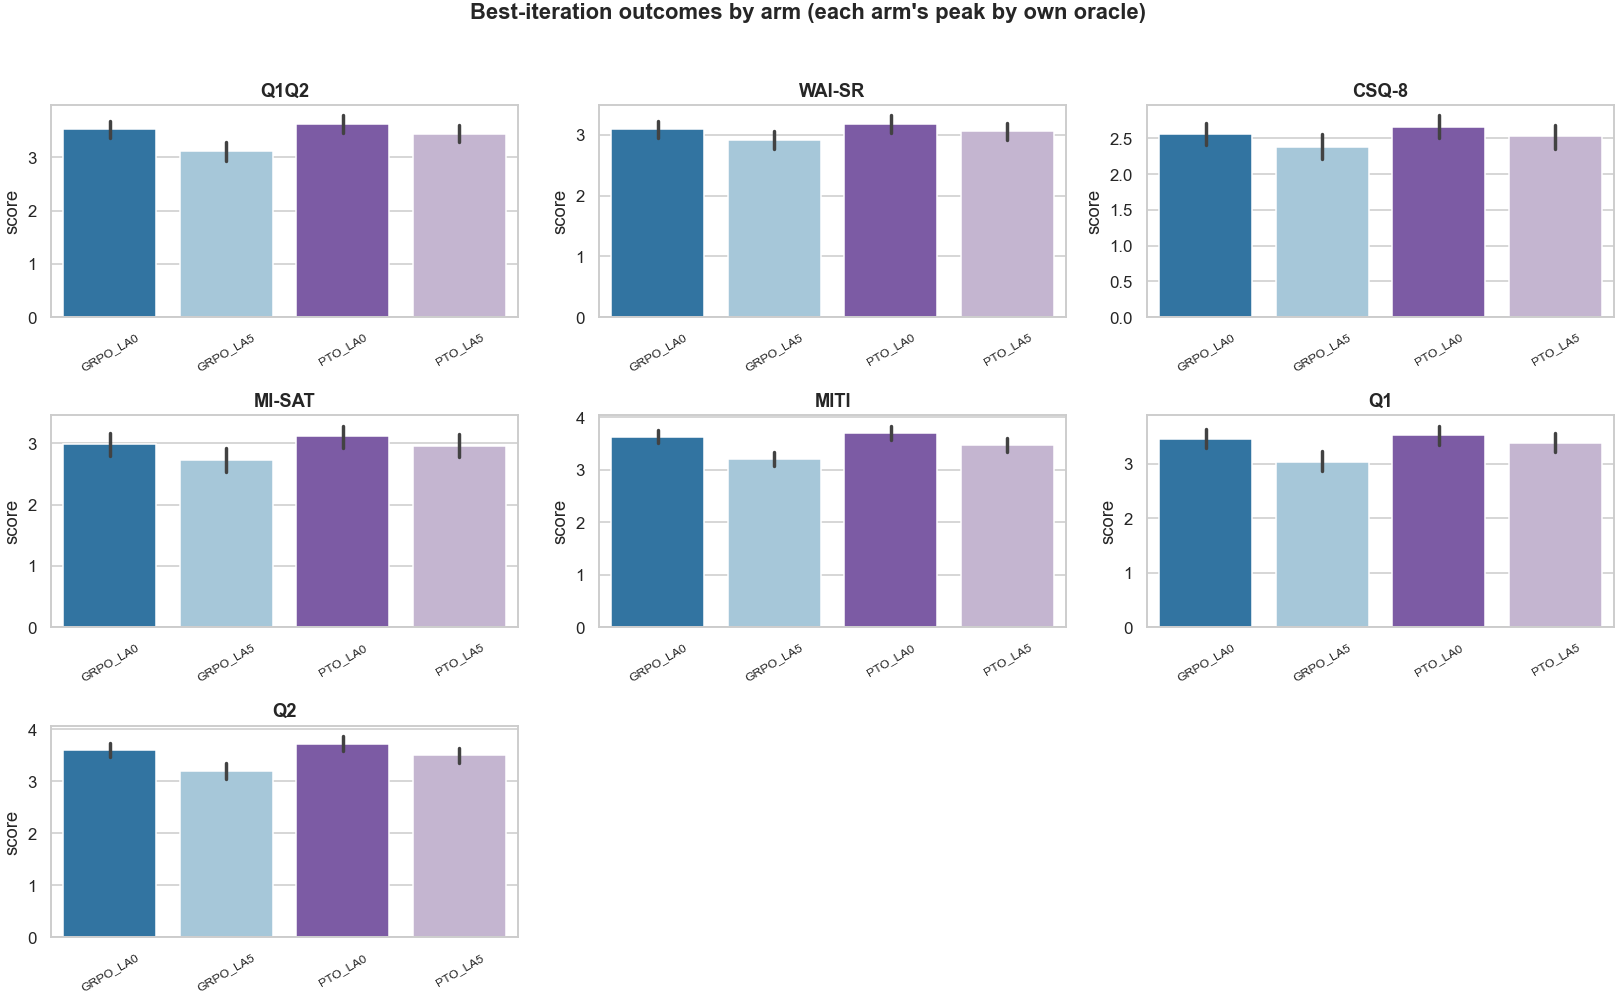

In [3]:
SEL, best = exp3.best_per_experiment(S.SCORES); display(best)
fig = plots.outcomes_headline_by_arm(SEL, palette=S.PALETTE)
exp3.save_fig(fig, "outcomes_headline", caption="Best iteration per arm (peak by own training oracle) across the MI rubrics; mean +/- 95% CI over 96 personas.")
plt.show()

## 3 · Q1+Q2 learning curve with oracle-noise reference band

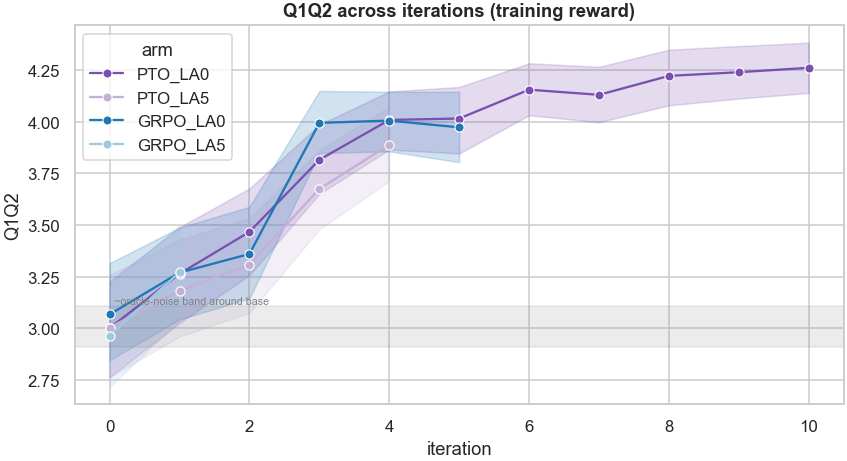

In [4]:
fig = plots.single_metric_trajectory(S.SCORES, "Q1Q2", palette=S.PALETTE, oracle_noise=S.ORACLE_NOISE)
exp3.save_fig(fig, "trajectory_Q1Q2", caption="Q1+Q2 mean across iterations per arm (mean +/- 95% CI, N=96). Grey band = oracle reproducibility (~0.10) around base: differences within it are at oracle-noise scale.")
plt.show()

## 4 · Reward faithfulness + rubric factor structure

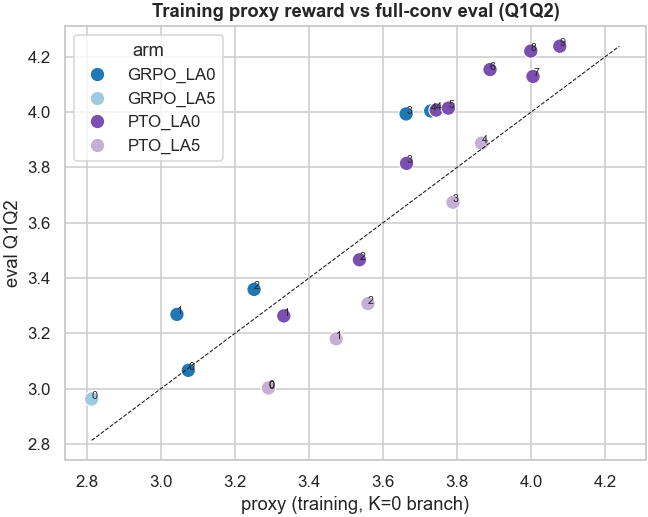

,arm,PC1_%
0,GRPO_LA0,92.1
1,GRPO_LA5,93.3
2,PTO_LA0,90.7
3,PTO_LA5,91.6


'C:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\eda\\results\\tables'

In [5]:
GENS = training.load_generations(S.ARMS)
fig = plots.faithfulness_proxy_vs_eval(S.SCORES, GENS)
if fig: exp3.save_fig(fig, "faithfulness_proxy_vs_eval", caption="Per (arm, iteration): mean training proxy reward (oracle on short branch) vs full-conversation eval Q1Q2; dashed y=x."); plt.show()
pca_rows = [{"arm": a, "PC1_%": round(100*stats.rubric_pca(S.SCORES[S.SCORES.arm==a])["explained_variance_ratio"][0], 1)}
            for a in sorted(S.SCORES.arm.unique()) if stats.rubric_pca(S.SCORES[S.SCORES.arm==a])["explained_variance_ratio"]]
PCA = pd.DataFrame(pca_rows); display(PCA)
exp3.save_table(PCA, "rubric_pca_pc1", caption="Variance explained by PC1 of the rubric scores per arm (dominant PC1 => rubrics ~ one latent factor).")

## 5 · Preference probe headline (PTO) — which words the policy prefers

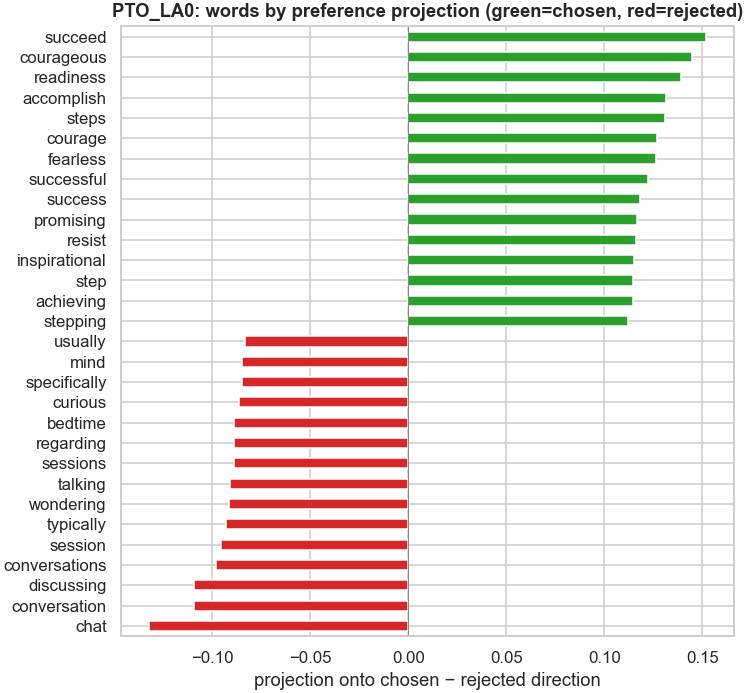

In [6]:
pto = [a for a in S.ARMS if a.method == "PTO" and len(training.load_pref_pairs([a]))]
if pto:
    arm = pto[0]
    PAIRS = pref.add_text_features(training.load_pref_pairs([arm])); EMB = pref.embed_pairs(PAIRS)
    DIRS = pref.preference_direction_by_iter(EMB)
    words, wmat = pref.embed_vocab(pref.build_vocab(PAIRS, top_n=3000)); WP = pref.word_projection(words, wmat, DIRS)
    fig = pref.pref_word_ranking(WP, title=f"{arm.label}: words by preference projection (green=chosen, red=rejected)")
    exp3.save_fig(fig, "pref_word_ranking", caption=f"{arm.label}: top words aligned with the chosen (green) vs rejected (red) preference direction (Mass Mean Probe, pooled over iterations).")
    plt.show()
else:
    print("No PTO arm with preference pairs scored yet.")

## 6 · Artifact index
Every canonical deliverable + its caption (the figures already rendered inline above; PDFs don't
embed inline). One scannable list of what `results/` now holds.

In [7]:
import glob
for sub, base, pat in [("figures", exp3.FIGURES_DIR, "*.pdf"), ("tables", exp3.TABLES_DIR, "*.md")]:
    files = sorted(os.path.basename(f) for f in glob.glob(os.path.join(base, pat)))
    print(f"=== results/{sub} ({len(files)}) ===")
    for f in files: print("  -", f)
    cap = os.path.join(base, "CAPTIONS.md")
    if os.path.exists(cap):
        print("--- captions ---"); print(open(cap, encoding="utf-8").read())

=== results/figures (4) ===
  - faithfulness_proxy_vs_eval.pdf
  - outcomes_headline.pdf
  - pref_word_ranking.pdf
  - trajectory_Q1Q2.pdf
--- captions ---
- **outcomes_headline** — Best iteration per arm (peak by own training oracle) across the MI rubrics; mean +/- 95% CI over 96 personas.
- **trajectory_Q1Q2** — Q1+Q2 mean across iterations per arm (mean +/- 95% CI, N=96). Grey band = oracle reproducibility (~0.10) around base: differences within it are at oracle-noise scale.
- **faithfulness_proxy_vs_eval** — Per (arm, iteration): mean training proxy reward (oracle on short branch) vs full-conversation eval Q1Q2; dashed y=x.
- **pref_word_ranking** — PTO_LA0: top words aligned with the chosen (green) vs rejected (red) preference direction (Mass Mean Probe, pooled over iterations).

=== results/tables (4) ===
  - CAPTIONS.md
  - friedman_omnibus.md
  - main_results_final.md
  - rubric_pca_pc1.md
--- captions ---
- **main_results_final** — Final iteration vs base, per arm x rubric. Pa